In [5]:
# ============================================================
# 1. Features für synthetische und echte Daten berechnen
# ============================================================

import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from lexicalrichness import LexicalRichness
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors


# ------------------------------------------------------------
# Pfade
# ------------------------------------------------------------

SYN_PATH = "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-Depression-Assessment-from-Therapy-Transcripts/OUTPUT/10_synthetic_transcripts_length_controlled_merged_turns.csv"
REAL_TRANSCRIPT_PATH = "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-Depression-Assessment-from-Therapy-Transcripts/INPUT/DAIC_FULL_NO_TAGS.csv"
REAL_META_PATH = "/home/jovyan/Exploring-LLM-Based-Feature-Extraction-for-Depression-Assessment-from-Therapy-Transcripts/INPUT/DAIC_META.csv"


# ------------------------------------------------------------
# Welche Strukturfeatures sollen evaluiert werden?
# ------------------------------------------------------------

STRUCTURE_FEATURES = [
    "n_turns",                              # Participant-Turns
    "total_participant_words",
    "mean_words_per_participant_turn",
    "median_words_per_participant_turn",
    "total_transcript_turns",
    "participant_therapist_turn_ratio",
]

# Optional: Wenn du Lexical Richness weiter mitlaufen lassen willst
LEXICAL_FEATURES = [
    "hdd",
    "yulek",
]

# Für die zentrale Evaluation würde ich erstmal nur Strukturfeatures nehmen.
EVAL_FEATURES = STRUCTURE_FEATURES

# Wenn du zusätzlich hdd/yulek plotten willst:
# EVAL_FEATURES = STRUCTURE_FEATURES + LEXICAL_FEATURES


# ------------------------------------------------------------
# Hilfsfunktionen
# ------------------------------------------------------------

WORD_RE = re.compile(r"[A-Za-z]+(?:'[A-Za-z]+)?|[0-9]+")


def count_words(text):
    """
    Zählt Wörter robust genug für diese Evaluation.
    """
    if pd.isna(text):
        return 0
    return len(WORD_RE.findall(str(text)))


def normalize_speaker(speaker):
    """
    Vereinheitlicht Speaker-Labels.
    Reale DAIC-Daten nutzen oft 'Ellie', synthetische Daten ggf. 'Therapist'.
    """
    speaker = str(speaker).strip().lower()

    if speaker == "participant":
        return "Participant"

    if speaker in ["ellie", "therapist", "interviewer"]:
        return "Therapist"

    return "Other"


def safe_lexical_features(text):
    """
    Berechnet hdd und yulek sicher.
    Falls ein Text leer/zu kurz/problematisch ist, kommt NaN zurück.
    """
    text = "" if pd.isna(text) else str(text).strip()

    if text == "":
        return pd.Series({
            "hdd": np.nan,
            "yulek": np.nan,
        })

    n_words = count_words(text)

    if n_words < 2:
        return pd.Series({
            "hdd": np.nan,
            "yulek": np.nan,
        })

    try:
        lex = LexicalRichness(text)

        # hdd mit draws=42 kann bei sehr kurzen Texten problematisch sein.
        # Deshalb wird draws an die Textlänge angepasst.
        draws = min(42, n_words)

        return pd.Series({
            "hdd": lex.hdd(draws=draws),
            "yulek": lex.yulek,
        })

    except Exception:
        return pd.Series({
            "hdd": np.nan,
            "yulek": np.nan,
        })


def calc_features(df, id_col, speaker_col="speaker", text_col="value"):
    """
    Berechnet pro Transkript:
    - n_turns = Anzahl Participant-Turns
    - total_participant_words
    - mean_words_per_participant_turn
    - median_words_per_participant_turn
    - total_transcript_turns
    - participant_therapist_turn_ratio
    - optional zusätzlich: hdd, yulek
    """
    data = df.copy()

    data[speaker_col] = data[speaker_col].fillna("").astype(str).str.strip()
    data[text_col] = data[text_col].fillna("").astype(str).str.strip()

    # Leere Zeilen entfernen
    data = data[data[text_col].str.len() > 0].copy()

    # Speaker normalisieren
    data["speaker_norm"] = data[speaker_col].apply(normalize_speaker)

    # Nur relevante Speaker behalten
    data = data[data["speaker_norm"].isin(["Participant", "Therapist"])].copy()

    # Wortanzahl pro Zeile
    data["word_count"] = data[text_col].apply(count_words)

    # Flags
    data["is_participant"] = data["speaker_norm"].eq("Participant")
    data["is_therapist"] = data["speaker_norm"].eq("Therapist")

    # Alle Turns pro Transkript
    all_turn_features = (
        data
        .groupby(id_col)
        .agg(
            total_transcript_turns=(text_col, "count"),
            participant_turns=("is_participant", "sum"),
            therapist_turns=("is_therapist", "sum"),
        )
        .reset_index()
    )

    # Nur Participant-Turns
    participant_data = data[data["speaker_norm"] == "Participant"].copy()

    participant_features = (
        participant_data
        .groupby(id_col)
        .agg(
            text=(text_col, lambda x: " ".join(x.astype(str))),
            n_turns=(text_col, "count"),
            total_participant_words=("word_count", "sum"),
            mean_words_per_participant_turn=("word_count", "mean"),
            median_words_per_participant_turn=("word_count", "median"),
        )
        .reset_index()
    )

    result_df = all_turn_features.merge(
        participant_features,
        on=id_col,
        how="left"
    )

    # Falls ein Transkript keine Participant-Zeilen hat
    result_df["text"] = result_df["text"].fillna("")
    result_df["n_turns"] = result_df["n_turns"].fillna(0)
    result_df["total_participant_words"] = result_df["total_participant_words"].fillna(0)

    # Ratio: Participant-Turns / Therapist-Turns
    result_df["participant_therapist_turn_ratio"] = (
        result_df["n_turns"] / result_df["therapist_turns"].replace(0, np.nan)
    )

    # Lexical Features weiter mitberechnen, auch wenn du sie nicht immer plottest
    lexical_df = result_df["text"].apply(safe_lexical_features)

    result_df = pd.concat(
        [result_df.reset_index(drop=True), lexical_df.reset_index(drop=True)],
        axis=1
    )

    # Schöne Spaltenreihenfolge
    ordered_cols = [
        id_col,
        "text",
        "n_turns",
        "total_participant_words",
        "mean_words_per_participant_turn",
        "median_words_per_participant_turn",
        "total_transcript_turns",
        "participant_therapist_turn_ratio",
        "participant_turns",
        "therapist_turns",
        "hdd",
        "yulek",
    ]

    existing_cols = [col for col in ordered_cols if col in result_df.columns]
    other_cols = [col for col in result_df.columns if col not in existing_cols]

    return result_df[existing_cols + other_cols]


# ============================================================
# 2. Synthetische Features berechnen
# ============================================================

df_syn = pd.read_csv(SYN_PATH, index_col=0)

# Spaltennamen vereinheitlichen
df_syn = df_syn.rename(columns={
    "Participant_ID": "synthetic_ID",
    "synthetic_id": "synthetic_ID",
    "utterance": "value",
})

syn_features = calc_features(
    df=df_syn,
    id_col="synthetic_ID",
    speaker_col="speaker",
    text_col="value",
)

syn_features.head()

KeyError: 'speaker'

In [4]:
pip install lexicalrichness

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.0/625.0 kB 3.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 12.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 801.3/801.3 kB 7.1 MB/s  0:00:00
  Created wheel for lexicalrichness: filename=lexicalrichness-0.5.1-py3-none-any.whl size=15506 sha256=65b3fc93698639e260f2340e8d0312c8f3a0426a3545974af58c5a5d4bc0d9bd
  Stored in directory: /home/jovyan/.cache/pip/wheels/eb/40/d0/053edb84485f223effdbf0f91fc2b6ec6fc6cf2230aadca09a
Successfully built lexicalrichness
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [lexicalrichness] [lexicalrichness]
Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# 3. PHQ-Nachbar:innen finden
# ============================================================

def find_neighbors_for_synthetic_df(
    real_features_path,
    syn_df,
    real_feature_cols,
    syn_feature_cols,
    k=5,
    real_id_col="Participant_ID",
    syn_id_col="synthetic_ID"
):
    real_df = pd.read_csv(real_features_path)

    real_needed = [real_id_col] + real_feature_cols
    real_df = real_df[real_needed].dropna().reset_index(drop=True)

    syn_needed = [syn_id_col] + syn_feature_cols
    syn_clean = syn_df[syn_needed].dropna().reset_index(drop=True)

    X_real = real_df[real_feature_cols].values
    X_syn = syn_clean[syn_feature_cols].values

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_syn_scaled = scaler.transform(X_syn)

    nn = NearestNeighbors(
        n_neighbors=k,
        metric="euclidean",
        algorithm="auto",
        n_jobs=-1
    )

    nn.fit(X_real_scaled)

    distances, indices = nn.kneighbors(
        X_syn_scaled,
        n_neighbors=k,
        return_distance=True
    )

    rows = []

    for syn_idx, syn_row in syn_clean.iterrows():
        synthetic_id = syn_row[syn_id_col]

        for rank in range(k):
            real_idx = indices[syn_idx, rank]
            distance = distances[syn_idx, rank]

            neighbor_row = real_df.iloc[real_idx].to_dict()

            rows.append({
                syn_id_col: synthetic_id,
                "neighbor_rank": rank + 1,
                "neighbor_distance": distance,
                **neighbor_row
            })

    neighbors_df = pd.DataFrame(rows)

    return neighbors_df


SYN_FEATURE_COLUMNS = [
    "target_PHQ8_Concentrating",
    "target_PHQ8_Appetite",
    "target_PHQ8_Depressed",
    "target_PHQ8_Tired",
    "target_PHQ8_NoInterest",
    "target_PHQ8_Failure",
    "target_PHQ8_Moving",
    "target_PHQ8_Sleep",
]

REAL_FEATURE_COLS = [
    "PHQ8_Concentrating",
    "PHQ8_Appetite",
    "PHQ8_Depressed",
    "PHQ8_Tired",
    "PHQ8_NoInterest",
    "PHQ8_Failure",
    "PHQ8_Moving",
    "PHQ8_Sleep",
]

neighbors_df = find_neighbors_for_synthetic_df(
    real_features_path=REAL_META_PATH,
    syn_df=df_syn,
    real_feature_cols=REAL_FEATURE_COLS,
    syn_feature_cols=SYN_FEATURE_COLUMNS,
    k=5,
    real_id_col="Participant_ID",
    syn_id_col="synthetic_ID"
)

neighbors_df.head()

,synthetic_ID,neighbor_rank,neighbor_distance,Participant_ID,PHQ8_Concentrating,PHQ8_Appetite,PHQ8_Depressed,PHQ8_Tired,PHQ8_NoInterest,PHQ8_Failure,PHQ8_Moving,PHQ8_Sleep
0,syn_0000,1,3.129850,321,3,3,3,3,2,3,0,3
1,syn_0000,2,3.231635,332,3,3,2,3,2,2,0,3
2,syn_0000,3,3.293923,354,3,3,2,3,1,2,1,3
3,syn_0000,4,3.313099,376,2,2,2,2,2,0,0,2
4,syn_0000,5,3.323195,384,3,2,2,2,2,2,1,1


In [3]:
# ============================================================
# 4. Features der echten Nachbar:innen berechnen
# ============================================================

df_real = pd.read_csv(
    REAL_TRANSCRIPT_PATH,
    usecols=["Participant_ID", "speaker", "value"]
)

neighbor_ids = neighbors_df["Participant_ID"].dropna().unique()

df_real_neighbors = df_real[
    df_real["Participant_ID"].isin(neighbor_ids)
].copy()

neighbor_features = calc_features(
    df=df_real_neighbors,
    id_col="Participant_ID",
    speaker_col="speaker",
    text_col="value",
)

neighbor_features.head()

,Participant_ID,text,n_turns,total_participant_words,mean_words_per_participant_turn,median_words_per_participant_turn,total_transcript_turns,participant_therapist_turn_ratio,participant_turns,therapist_turns,hdd,yulek
0,304,i'm doing good um from los angeles california ...,104,977,9.394231,4.0,201,1.072165,104,97,0.830129,119.701896
1,305,i'm doing alright uh originally i'm from calif...,288,3327,11.552083,7.0,404,2.482759,288,116,0.772369,179.830204
2,308,los angeles california yes um the southern cal...,151,885,5.860927,5.0,221,2.157143,151,70,0.806485,148.502733
3,309,yeah i'm doing good uh arizona uh because of a...,88,679,7.715909,5.0,170,1.073171,88,82,0.812845,149.129817
4,311,yes okay uh when'd i move to l_a um moved here...,126,632,5.015873,4.0,221,1.326316,126,95,0.798750,142.590302


In [4]:
# ============================================================
# 5. Synthetische Transkripte mit echten Nachbar:innen vergleichen
# ============================================================

neighbor_feature_cols = [
    "text",
    "n_turns",
    "total_participant_words",
    "mean_words_per_participant_turn",
    "median_words_per_participant_turn",
    "total_transcript_turns",
    "participant_therapist_turn_ratio",
    "participant_turns",
    "therapist_turns",
    "hdd",
    "yulek",
]

neighbors_with_features = neighbors_df.merge(
    neighbor_features[["Participant_ID"] + neighbor_feature_cols],
    on="Participant_ID",
    how="left"
)

# Nur zur Kontrolle
neighbors_with_features.head()

,synthetic_ID,neighbor_rank,neighbor_distance,Participant_ID,PHQ8_Concentrating,PHQ8_Appetite,PHQ8_Depressed,PHQ8_Tired,PHQ8_NoInterest,PHQ8_Failure,...,n_turns,total_participant_words,mean_words_per_participant_turn,median_words_per_participant_turn,total_transcript_turns,participant_therapist_turn_ratio,participant_turns,therapist_turns,hdd,yulek
0,syn_0000,1,3.129850,321,3,3,3,3,2,3,...,122.0,911.0,7.467213,4.0,232.0,1.109091,122.0,110.0,0.789422,185.312516
1,syn_0000,2,3.231635,332,3,3,2,3,2,2,...,147.0,857.0,5.829932,3.0,241.0,1.563830,147.0,94.0,0.809903,134.993460
2,syn_0000,3,3.293923,354,3,3,2,3,1,2,...,82.0,488.0,5.951220,3.0,176.0,0.872340,82.0,94.0,0.818660,130.030513
3,syn_0000,4,3.313099,376,2,2,2,2,2,0,...,196.0,1701.0,8.678571,6.5,267.0,2.760563,196.0,71.0,0.817541,141.091843
4,syn_0000,5,3.323195,384,3,2,2,2,2,2,...,155.0,1100.0,7.096774,6.0,247.0,1.684783,155.0,92.0,0.819659,133.388099


In [5]:
# ============================================================
# 6. Nachbar:innen-Mittelwerte, Mediane und Streuung berechnen
# ============================================================

def build_neighbor_summary(neighbors_with_features, features):
    agg_dict = {}

    for feature in features:
        agg_dict[f"neighbor_{feature}_mean"] = (feature, "mean")
        agg_dict[f"neighbor_{feature}_median"] = (feature, "median")
        agg_dict[f"neighbor_{feature}_std"] = (feature, "std")
        agg_dict[f"neighbor_{feature}_min"] = (feature, "min")
        agg_dict[f"neighbor_{feature}_max"] = (feature, "max")

    summary = (
        neighbors_with_features
        .groupby("synthetic_ID")
        .agg(**agg_dict)
        .reset_index()
    )

    return summary


neighbor_feature_summary = build_neighbor_summary(
    neighbors_with_features=neighbors_with_features,
    features=EVAL_FEATURES
)

comparison_df = syn_features.merge(
    neighbor_feature_summary,
    on="synthetic_ID",
    how="left"
)

comparison_df.head()

,synthetic_ID,text,n_turns,total_participant_words,mean_words_per_participant_turn,median_words_per_participant_turn,total_transcript_turns,participant_therapist_turn_ratio,participant_turns,therapist_turns,...,neighbor_total_transcript_turns_mean,neighbor_total_transcript_turns_median,neighbor_total_transcript_turns_std,neighbor_total_transcript_turns_min,neighbor_total_transcript_turns_max,neighbor_participant_therapist_turn_ratio_mean,neighbor_participant_therapist_turn_ratio_median,neighbor_participant_therapist_turn_ratio_std,neighbor_participant_therapist_turn_ratio_min,neighbor_participant_therapist_turn_ratio_max
0,syn_0000,I've been feeling pretty down most days. Thing...,7.0,197.0,28.142857,30.0,14,1.000000,7,7,...,232.60,241.0,30.766253,176.0,267.0,1.598121,1.563830,0.656761,0.872340,2.760563
1,syn_0001,"I've been okay, just finding it harder to stay...",8.0,175.0,21.875000,23.0,17,0.888889,8,9,...,258.00,276.0,44.693400,184.0,303.0,1.885612,1.729412,0.636670,1.319328,3.040000
2,syn_0002,"I'm managing, but I’m pretty exhausted and it’...",8.0,152.0,19.000000,18.5,17,0.888889,8,9,...,248.75,265.0,47.442463,170.0,295.0,2.104452,1.955651,0.854793,1.073171,3.433333
3,syn_0003,"I'm okay, just a bit scattered with work but o...",10.0,211.0,21.100000,20.5,21,0.909091,10,11,...,267.60,295.0,83.417693,165.0,372.0,1.987207,2.010204,1.014899,0.872340,3.769231
4,syn_0004,"Honestly, I’ve been feeling pretty foggy—like ...",9.0,270.0,30.000000,29.0,19,0.900000,9,10,...,250.50,243.5,31.323474,221.0,294.0,2.840309,2.795238,1.199959,1.326316,4.444444


In [6]:
# ============================================================
# 7. Differenzen berechnen
# ============================================================

def add_difference_columns(comparison_df, features):
    df = comparison_df.copy()

    for feature in features:
        syn_col = feature
        neigh_mean_col = f"neighbor_{feature}_mean"
        neigh_std_col = f"neighbor_{feature}_std"

        if syn_col not in df.columns or neigh_mean_col not in df.columns:
            print(f"Überspringe {feature}: Spalte fehlt.")
            continue

        df[f"{feature}_diff"] = df[syn_col] - df[neigh_mean_col]
        df[f"{feature}_abs_diff"] = df[f"{feature}_diff"].abs()

        df[f"{feature}_percent_diff"] = (
            df[f"{feature}_diff"] / df[neigh_mean_col].replace(0, np.nan) * 100
        )

        df[f"{feature}_abs_percent_diff"] = df[f"{feature}_percent_diff"].abs()

        # Standardisierte Abweichung:
        # Wie viele Nachbar:innen-Standardabweichungen liegt synthetic vom Nachbar:innen-Mittel weg?
        if neigh_std_col in df.columns:
            df[f"{feature}_z_diff"] = (
                df[f"{feature}_diff"] / df[neigh_std_col].replace(0, np.nan)
            )

    return df


comparison_df = add_difference_columns(
    comparison_df=comparison_df,
    features=EVAL_FEATURES
)

In [7]:
# ============================================================
# 8. Übersichtstabelle
# ============================================================

overview_cols = ["synthetic_ID"]

for feature in EVAL_FEATURES:
    overview_cols += [
        feature,
        f"neighbor_{feature}_mean",
        f"{feature}_diff",
        f"{feature}_abs_percent_diff",
        f"{feature}_z_diff",
    ]

overview_cols = [col for col in overview_cols if col in comparison_df.columns]

comparison_overview = comparison_df[overview_cols].copy()

comparison_overview.head()

,synthetic_ID,n_turns,neighbor_n_turns_mean,n_turns_diff,n_turns_abs_percent_diff,n_turns_z_diff,total_participant_words,neighbor_total_participant_words_mean,total_participant_words_diff,total_participant_words_abs_percent_diff,...,total_transcript_turns,neighbor_total_transcript_turns_mean,total_transcript_turns_diff,total_transcript_turns_abs_percent_diff,total_transcript_turns_z_diff,participant_therapist_turn_ratio,neighbor_participant_therapist_turn_ratio_mean,participant_therapist_turn_ratio_diff,participant_therapist_turn_ratio_abs_percent_diff,participant_therapist_turn_ratio_z_diff
0,syn_0000,7.0,140.40,-133.40,95.014245,-3.515385,197.0,1011.40,-814.40,80.522049,...,14,232.60,-218.60,93.981083,-7.105188,1.000000,1.598121,-0.598121,37.426532,-0.910714
1,syn_0001,8.0,166.80,-158.80,95.203837,-3.728167,175.0,1091.00,-916.00,83.959670,...,17,258.00,-241.00,93.410853,-5.392295,0.888889,1.885612,-0.996723,52.859383,-1.565524
2,syn_0002,8.0,166.00,-158.00,95.180723,-3.364033,152.0,1199.00,-1047.00,87.322769,...,17,248.75,-231.75,93.165829,-4.884864,0.888889,2.104452,-1.215563,57.761499,-1.422056
3,syn_0003,10.0,177.20,-167.20,94.356659,-2.046196,211.0,1317.00,-1106.00,83.978740,...,21,267.60,-246.60,92.152466,-2.956207,0.909091,1.987207,-1.078116,54.252835,-1.062289
4,syn_0004,9.0,180.75,-171.75,95.020747,-3.807786,270.0,1349.25,-1079.25,79.988883,...,19,250.50,-231.50,92.415170,-7.390623,0.900000,2.840309,-1.940309,68.313308,-1.616980


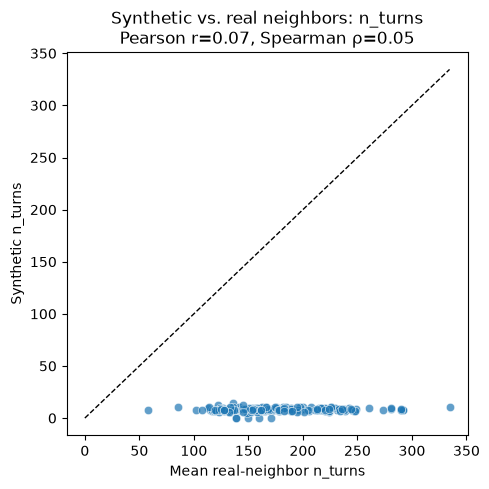

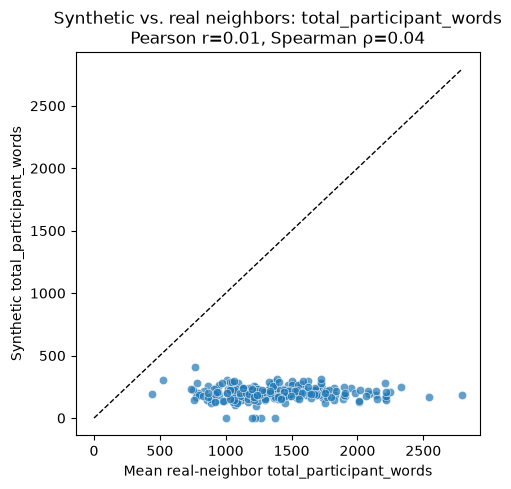

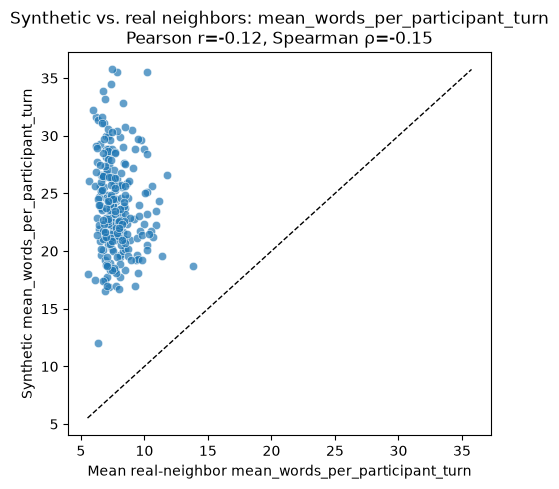

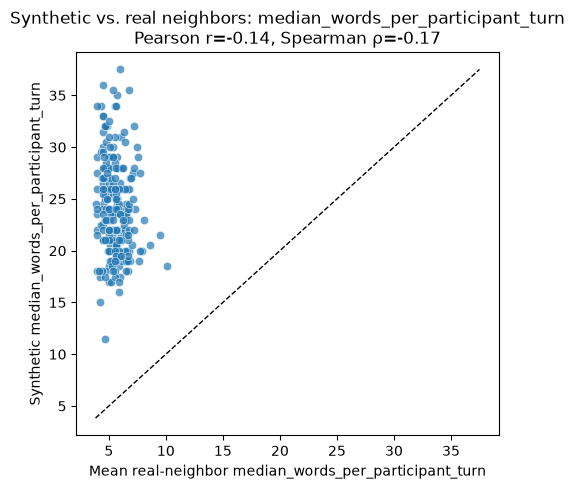

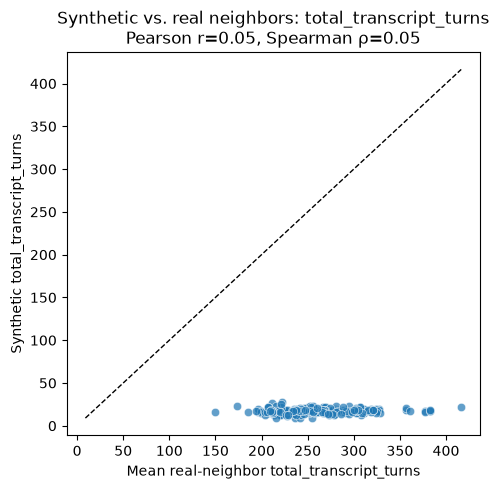

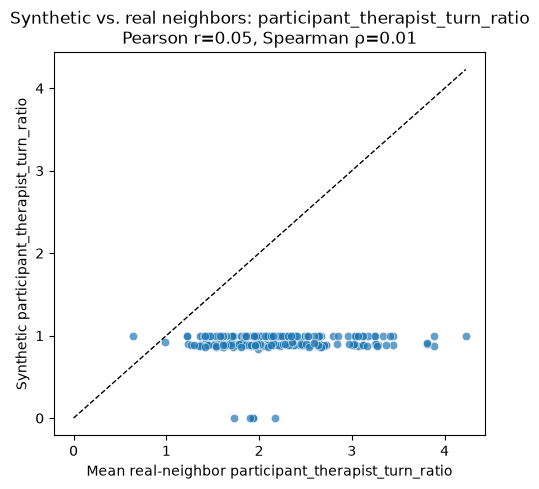

In [8]:
# ============================================================
# 9. Plot 1: Synthetic vs. real-neighbor mean
# ============================================================

def plot_syn_vs_neighbor_mean(comparison_df, features):
    for feature in features:
        syn_col = feature
        neigh_col = f"neighbor_{feature}_mean"

        if syn_col not in comparison_df.columns or neigh_col not in comparison_df.columns:
            print(f"Überspringe {feature}: Spalte fehlt.")
            continue

        plot_df = comparison_df[[syn_col, neigh_col]].dropna()

        if len(plot_df) < 3:
            print(f"Zu wenige Daten für {feature}")
            continue

        pearson_r, pearson_p = pearsonr(plot_df[neigh_col], plot_df[syn_col])
        spearman_r, spearman_p = spearmanr(plot_df[neigh_col], plot_df[syn_col])

        min_val = min(plot_df[syn_col].min(), plot_df[neigh_col].min())
        max_val = max(plot_df[syn_col].max(), plot_df[neigh_col].max())

        plt.figure(figsize=(5, 5))

        sns.scatterplot(
            data=plot_df,
            x=neigh_col,
            y=syn_col,
            alpha=0.7
        )

        plt.plot(
            [min_val, max_val],
            [min_val, max_val],
            linestyle="--",
            color="black",
            linewidth=1
        )

        plt.xlabel(f"Mean real-neighbor {feature}")
        plt.ylabel(f"Synthetic {feature}")
        plt.title(
            f"Synthetic vs. real neighbors: {feature}\n"
            f"Pearson r={pearson_r:.2f}, Spearman ρ={spearman_r:.2f}"
        )

        plt.tight_layout()
        plt.show()


plot_syn_vs_neighbor_mean(
    comparison_df=comparison_df,
    features=EVAL_FEATURES
)

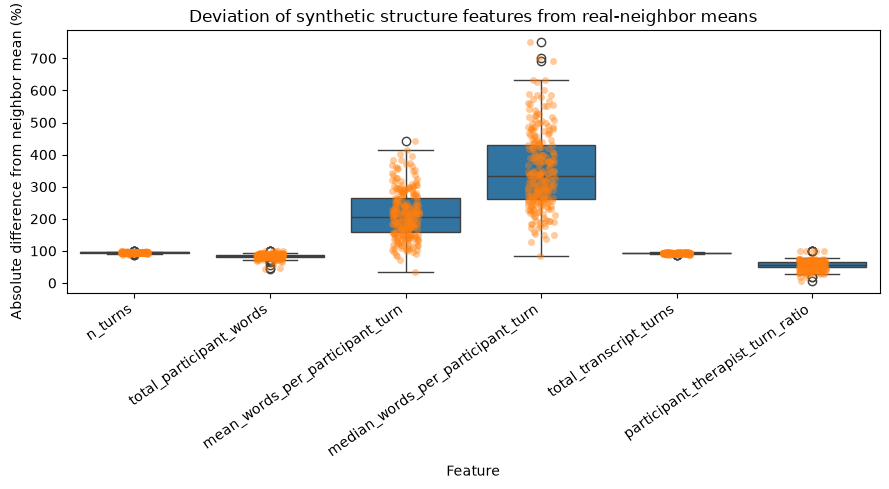

In [9]:
# ============================================================
# 10. Plot 2: Absolute prozentuale Abweichung
# ============================================================

def plot_absolute_percent_differences(comparison_df, features):
    rows = []

    for feature in features:
        col = f"{feature}_abs_percent_diff"

        if col not in comparison_df.columns:
            continue

        temp = comparison_df[[col]].dropna()

        for value in temp[col]:
            rows.append({
                "feature": feature,
                "absolute_percent_difference": value
            })

    plot_df = pd.DataFrame(rows)

    if plot_df.empty:
        print("Keine Daten für Plot vorhanden.")
        return

    plt.figure(figsize=(9, 5))

    sns.boxplot(
        data=plot_df,
        x="feature",
        y="absolute_percent_difference"
    )

    sns.stripplot(
        data=plot_df,
        x="feature",
        y="absolute_percent_difference",
        alpha=0.4
    )

    plt.xticks(rotation=35, ha="right")
    plt.xlabel("Feature")
    plt.ylabel("Absolute difference from neighbor mean (%)")
    plt.title("Deviation of synthetic structure features from real-neighbor means")
    plt.tight_layout()
    plt.show()


plot_absolute_percent_differences(
    comparison_df=comparison_df,
    features=EVAL_FEATURES
)

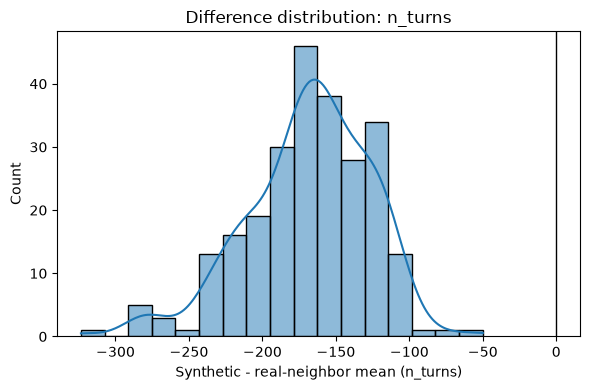

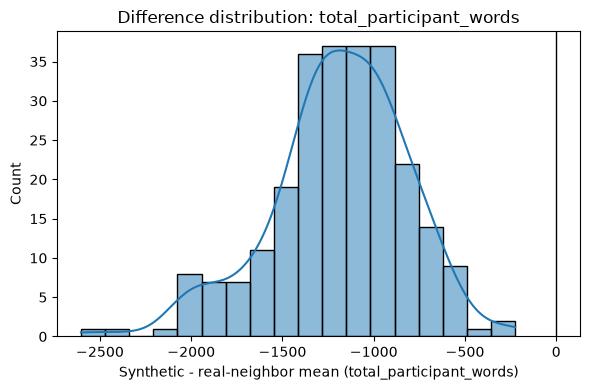

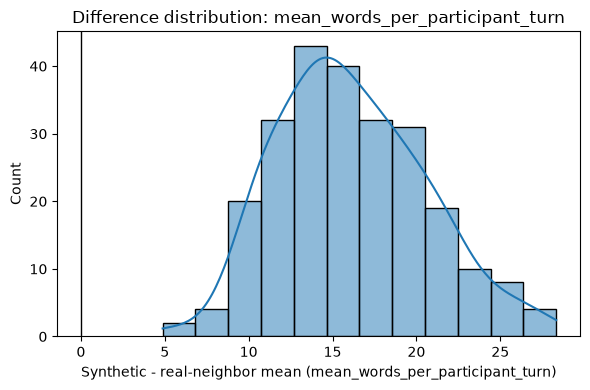

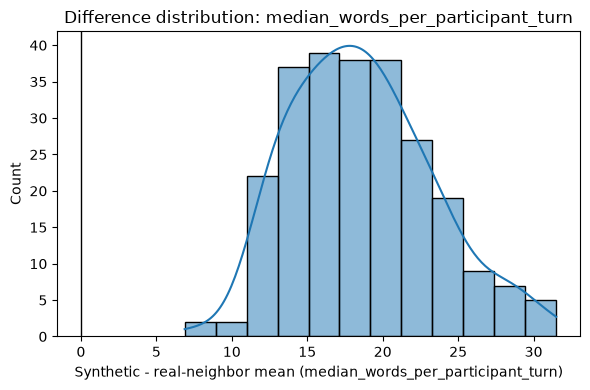

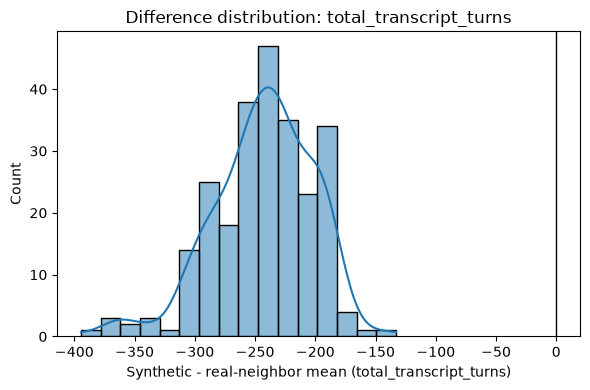

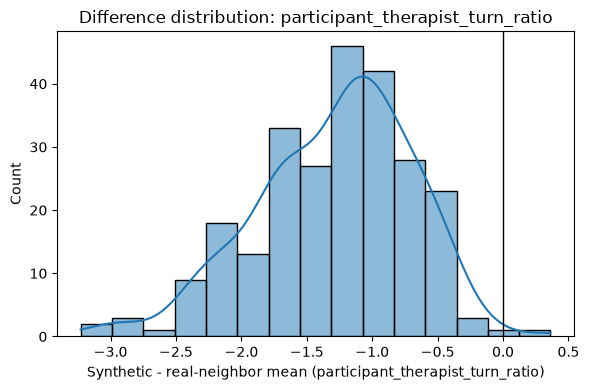

In [10]:
# ============================================================
# 11. Plot 3: Differenzverteilung
# ============================================================

def plot_difference_distribution(comparison_df, features):
    for feature in features:
        diff_col = f"{feature}_diff"

        if diff_col not in comparison_df.columns:
            print(f"Überspringe {feature}: {diff_col} fehlt.")
            continue

        plot_df = comparison_df[[diff_col]].dropna()

        if plot_df.empty:
            print(f"Keine Daten für {feature}")
            continue

        plt.figure(figsize=(6, 4))

        sns.histplot(
            data=plot_df,
            x=diff_col,
            kde=True
        )

        plt.axvline(0, color="black", linewidth=1)

        plt.xlabel(f"Synthetic - real-neighbor mean ({feature})")
        plt.ylabel("Count")
        plt.title(f"Difference distribution: {feature}")

        plt.tight_layout()
        plt.show()


plot_difference_distribution(
    comparison_df=comparison_df,
    features=EVAL_FEATURES
)

In [11]:
# ============================================================
# 12. Kompakter Ergebnis-Summary
# ============================================================

def summarize_feature_deviation(comparison_df, features):
    rows = []

    for feature in features:
        diff_col = f"{feature}_diff"
        abs_percent_col = f"{feature}_abs_percent_diff"
        z_col = f"{feature}_z_diff"

        if diff_col not in comparison_df.columns:
            continue

        temp = comparison_df[[feature, f"neighbor_{feature}_mean", diff_col, abs_percent_col, z_col]].replace(
            [np.inf, -np.inf],
            np.nan
        )

        rows.append({
            "feature": feature,
            "synthetic_mean": temp[feature].mean(),
            "neighbor_mean": temp[f"neighbor_{feature}_mean"].mean(),
            "mean_diff": temp[diff_col].mean(),
            "median_diff": temp[diff_col].median(),
            "mean_abs_percent_diff": temp[abs_percent_col].mean(),
            "median_abs_percent_diff": temp[abs_percent_col].median(),
            "mean_abs_z_diff": temp[z_col].abs().mean(),
            "median_abs_z_diff": temp[z_col].abs().median(),
        })

    return pd.DataFrame(rows)


structure_summary = summarize_feature_deviation(
    comparison_df=comparison_df,
    features=EVAL_FEATURES
)

structure_summary

,feature,synthetic_mean,neighbor_mean,mean_diff,median_diff,mean_abs_percent_diff,median_abs_percent_diff,mean_abs_z_diff,median_abs_z_diff
0,n_turns,8.376000,177.038267,-168.662267,-165.000000,95.001920,95.230208,4.761494,2.792998
1,total_participant_words,199.900000,1389.219933,-1189.319933,-1184.425000,84.484127,85.486545,2.400202,1.936087
2,mean_words_per_participant_turn,23.910503,7.795129,16.115201,15.551180,214.268075,206.394272,15.945775,9.708785
3,median_words_per_participant_turn,24.157143,5.539500,18.624082,18.250000,351.047928,334.782609,18.979734,14.626542
4,total_transcript_turns,17.480000,260.631667,-243.151667,-239.416667,93.133510,93.320978,5.796020,4.125131
5,participant_therapist_turn_ratio,0.921065,2.207225,-1.286159,-1.194353,55.640652,56.277062,2.092849,1.364718
